In [ ]:
import yaml
from importlib import reload
import agents
reload(agents)
from agents import QLearner, BehavioralLearner, KBandit, RandEnv
from agents import generate_behavioral_data

In [41]:
# catie_data = generate_behavioral_data(CatieAgent, num_episodes=1000)
q_learner = QLearner(alpha = 0.05, gamma = 0.95, epsilon = 0.2)
env = KBandit(n_arms=2, reward_type="binary", stationary=True)
train_data = generate_behavioral_data(q_learner, env, num_episodes=1000)
test_data = generate_behavioral_data(q_learner, env, num_episodes=1000)

In [72]:
target[50]

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])

In [57]:
input, target = behav_learner._preprocess_data(train_data)

In [15]:
behav_learner = BehavioralLearner(input_size=2, hidden_size=8, output_size=2, n_epochs=300, lr=0.01)
behav_learner.train_from_data(train_data)


--- BehavioralLearner 사전 학습 시작 (Batch Size: 32) ---


BehavioralLearner Training:   0%|          | 1/300 [00:00<03:48,  1.31it/s]

Epoch [1/300], Avg Loss: 0.6284


BehavioralLearner Training:  17%|█▋        | 50/300 [00:37<03:09,  1.32it/s]

Epoch [50/300], Avg Loss: 0.4357


...

Epoch [200/300], Avg Loss: 0.4330


BehavioralLearner Training:  83%|████████▎ | 250/300 [03:09<00:37,  1.32it/s]

Epoch [250/300], Avg Loss: 0.4327


BehavioralLearner Training: 100%|██████████| 300/300 [03:47<00:00,  1.32it/s]

Epoch [300/300], Avg Loss: 0.4346
--- BehavioralLearner 사전 학습 완료 (Final Loss: 0.4346) ---


In [73]:
reload(agents)
from agents import BehavioralLearner
acc_train, pred_train = behav_learner.evaluate(train_data)
acc_test, pred_test = behav_learner.evaluate(test_data)




--- BehavioralLearner 평가 시작 (Batch Size: 32) ---
--- 평가 완료: Accuracy = 87.93% (87052 / 99000 맞음) ---

--- BehavioralLearner 평가 시작 (Batch Size: 32) ---
--- 평가 완료: Accuracy = 87.80% (86919 / 99000 맞음) ---


In [83]:
pred_test[15:20]

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [86]:
behav_learner_data = generate_behavioral_data(behav_learner, env, num_episodes=10, episode_length=100)

In [88]:
env_rand = RandEnv(n_arms=2)
rand_data = generate_behavioral_data(behav_learner, env_rand, num_episodes=10, episode_length=100)

NameError: name 'RandEnv' is not defined

In [38]:
import numpy as np
import matplotlib.pyplot as plt
rew = np.zeros(1000)
for k in range(1000):
    rew[k]=behav_learner_data[0][k][1]
# plt.plot(np.cumsum(cnt))
# plt.show()

In [39]:
rew

array([0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0.,
       1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1.,
       1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1., 0., 0.,
       0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1.,
       1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1.,
       1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0.,
       0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1.,
       1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
       1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 0.,
       0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 0., 0., 1., 1.

In [119]:
test_data = generate_behavioral_data(q_learner, num_episodes=1000)

In [210]:
test_data[10]

[(0, 1),
 (0, 0),
 (0, 1),
 (1, 0),
 (0, 1),
 (0, 1),
 (0, 0),
 (0, 0),
 (0, 1),
 (0, 0),
 (0, 1),
 (0, 1),
 (0, 0),
 (0, 1),
 (0, 0),
 (0, 0),
 (0, 1),
 (0, 1),
 (0, 0),
 (1, 0),
 (0, 0),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 0),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 0),
 (0, 1),
 (1, 0),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 1),
 (0, 0),
 (0, 0),
 (1, 0),
 (0, 1),
 (0, 1),
 (0, 1),
 (0, 0),
 (0, 0),
 (0, 1),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (1, 1),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (1, 0),
 (0, 0),
 (1, 1),
 (1, 0),
 (1, 1),
 (1, 0),
 (1, 1),
 (1, 0),
 (1, 1),
 (1, 0),
 (1, 1),
 (1, 0),
 (1, 0),
 (1, 1),
 (1, 1),
 (1, 0),
 (1, 1),
 (1, 0),
 (1, 0),
 (1, 1),
 (1, 1),
 (1, 0),
 (1, 1),
 (1, 0),
 (0, 0),
 (1, 0),
 (1, 0),
 (1, 1),
 (1, 0),
 (1, 1),
 (1, 1)]

In [139]:
catie_agent = CatieAgent()
train_data_catie = generate_behavioral_data(catie_agent, num_episodes=1000)
test_data_catie = generate_behavioral_data(catie_agent, num_episodes=1000)

In [140]:
behav_learner_catie = BehavioralLearner(input_size=2, hidden_size=8, output_size=2, n_epochs=300, lr=0.01)
behav_learner_catie.train_from_data(train_data_catie)

acc_train, pred_train = behav_learner_catie.evaluate(train_data_catie)
acc_test, pred_test = behav_learner_catie.evaluate(test_data_catie)


--- BehavioralLearner 사전 학습 시작 (Batch Size: 32) ---


BehavioralLearner Training:   0%|          | 1/300 [00:00<04:08,  1.20it/s]

Epoch [1/300], Avg Loss: 0.6164


BehavioralLearner Training:  17%|█▋        | 50/300 [00:40<03:20,  1.25it/s]

Epoch [50/300], Avg Loss: 0.4465


...

BehavioralLearner Training:  83%|████████▎ | 250/300 [03:20<00:39,  1.26it/s]

Epoch [250/300], Avg Loss: 0.4433


BehavioralLearner Training: 100%|██████████| 300/300 [04:01<00:00,  1.24it/s]

Epoch [300/300], Avg Loss: 0.4435
--- BehavioralLearner 사전 학습 완료 (Final Loss: 0.4435) ---

--- BehavioralLearner 평가 시작 (Batch Size: 32) ---


--- 평가 완료: Accuracy = 86.97% (86102 / 99000 맞음) ---

--- BehavioralLearner 평가 시작 (Batch Size: 32) ---
--- 평가 완료: Accuracy = 86.84% (85967 / 99000 맞음) ---


In [148]:
reload(agents)
from agents import BehavioralLearner
acc_train, pred_train = behav_learner_catie.evaluate(train_data)
acc_test, pred_test = behav_learner_catie.evaluate(test_data)




--- BehavioralLearner 평가 시작 (Batch Size: 32) ---
--- 평가 완료: Accuracy = 90.92% (90008 / 99000 맞음) ---

--- BehavioralLearner 평가 시작 (Batch Size: 32) ---
--- 평가 완료: Accuracy = 90.77% (89866 / 99000 맞음) ---


In [202]:
reload(agents)
from agents import BehavioralLearner, Experiment
experiment_catie = Experiment(learner_template = behav_learner_catie)
target_action_counts_catie, adv_act, learner_act = experiment_catie.run(is_training=True)
experiment_catie.save_adversary("adv_behavioral_learner_catie.pth")

Using device: cpu


TypeError: AdversaryAgent.__init__() missing 1 required positional argument: 'learner'

In [170]:
experiment_catie.load_adversary("adv_behavioral_learner_catie.pth")
target_action_counts_test, adv_actions_test, learner_actions_test = experiment_catie.run(is_training=False)

/Users/sskim/Documents/Research/Study/CCN_Course/Tutorial-DecisionMaking/agents.py:555: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path, map_locat


--- adv_behavioral_learner_catie.pth 에서 Adversary 가중치 불러오는 중... ---
--- 불러오기 완료 ---

--- Evaluation 시작 (Learner: BehavioralLearner) ---


Evaluation: 100%|██████████| 100/100 [00:06<00:00, 15.51it/s]


--- Adversary 행동 로그 (첫 번째 평가 에피소드) ---
Adversary가 보상을 '주려고 시도한' 팔 (예산 소진 여부와 무관):
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [208]:
reload(agents)
from agents import BehavioralLearner, Experiment, AdversaryAgent
experiment = Experiment(learner_template = behav_learner)
target_action_counts, adv_act, learner_act = experiment.run(is_training=True)
experiment.save_adversary("adv_behavioral_learner.pth")

Using device: cpu

--- Adversary Training 시작 (Learner: BehavioralLearner) ---


Adversary Training:   0%|          | 2/2000 [00:00<03:10, 10.51it/s]

Episode 1, Loss: 0.6367, Reward: 100
Episode 2, Loss: 0.6291, Reward: 100


Adversary Training:   0%|          | 4/2000 [00:00<03:20,  9.96it/s]

Episode 3, Loss: 0.6172, Reward: 100
Episode 4, Loss: 0.6079, Reward: 100


...

Adversary Training:   2%|▏         | 30/2000 [00:03<03:41,  8.88it/s]

Episode 29, Loss: 0.4166, Reward: 100
Episode 30, Loss: 0.4066, Reward: 100


Adversary Training:   2%|▏         | 31/2000 [00:03<03:42,  8.84it/s]

Episode 31, Loss: 0.4097, Reward: 100


KeyboardInterrupt: 

In [181]:
experiment.load_adversary("adv_behavioral_learner.pth")
target_action_counts_test, adv_actions_test, learner_actions_test = experiment.run(is_training=False)

/Users/sskim/Documents/Research/Study/CCN_Course/Tutorial-DecisionMaking/agents.py:555: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path, map_locat


--- adv_behavioral_learner.pth 에서 Adversary 가중치 불러오는 중... ---
--- 불러오기 완료 ---

--- Evaluation 시작 (Learner: BehavioralLearner) ---


Evaluation: 100%|██████████| 100/100 [00:06<00:00, 16.27it/s]


--- Adversary 행동 로그 (첫 번째 평가 에피소드) ---
Adversary가 보상을 '주려고 시도한' 팔 (예산 소진 여부와 무관):
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [192]:
np.array(adv_actions_test).mean()

0.75

In [182]:
np.mean(target_action_counts_test)

79.95

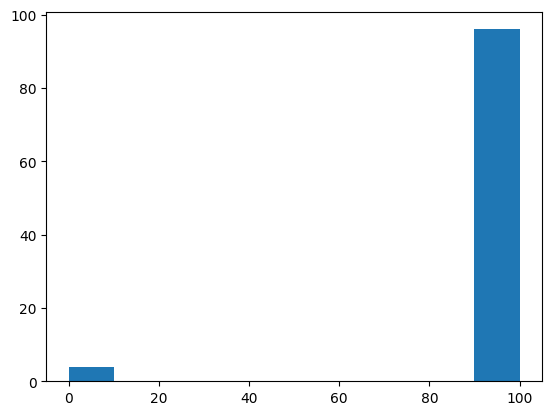

95.98


In [172]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist(target_action_counts_test)
plt.show()
print(np.mean(target_action_counts_test))

In [97]:
print("--- Adversary 평가 시작 ---")
final_counts = experiment.run(is_training=False)

# 이 'final_counts'가 진짜 결과입니다.
print(final_counts)

--- Adversary 평가 시작 ---

--- Evaluation 시작 (Learner: BehavioralLearner) ---


Evaluation: 100%|██████████| 100/100 [00:05<00:00, 16.75it/s]


--- Adversary 행동 로그 (첫 번째 평가 에피소드) ---
Adversary가 보상을 '주려고 시도한' 팔 (예산 소진 여부와 무관):
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
([100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0

In [101]:
final_counts[1]

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

--- Adversary 평가 시작 ---

--- Evaluation 시작 (Learner: BehavioralLearner) ---


Evaluation: 100%|██████████| 100/100 [00:06<00:00, 16.45it/s]
/Users/sskim/anaconda3/envs/motornet/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sskim/anaconda3/envs/motornet/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sskim/anaconda3/envs/motornet/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sskim/anaconda3/envs/motornet/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sskim/anaconda3/envs/motornet/lib/p


평가 완료. 평균 목표 행동(0) 선택 비율: 100.00%


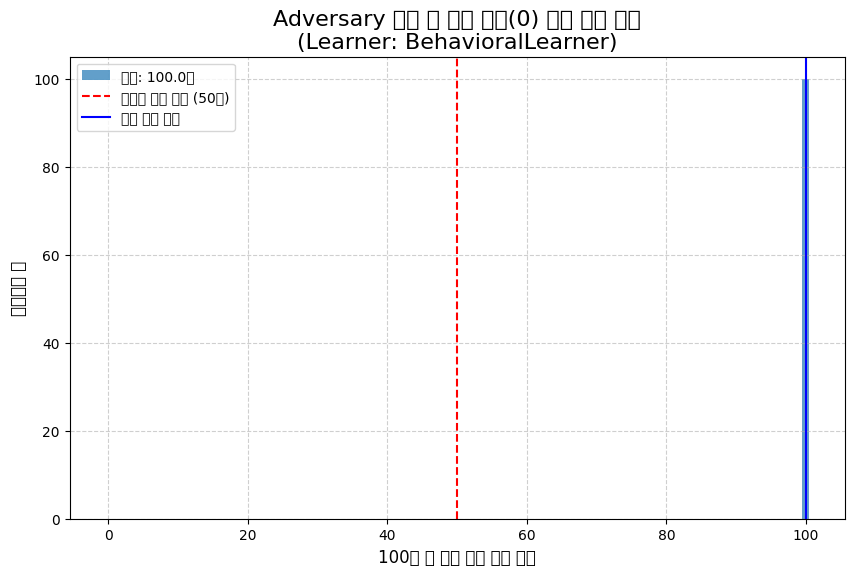


--- Adversary 행동 로그 (첫 번째 평가 에피소드) ---
Adversary가 보상을 '주려고 시도한' 팔 (예산 소진 여부와 무관):
[1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
([100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100], [1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1

In [84]:
target_action_counts

[100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100

In [69]:
final_counts

[98,
 99,
 98,
 99,
 0,
 99,
 98,
 99,
 99,
 99,
 0,
 99,
 97,
 98,
 98,
 99,
 1,
 99,
 0,
 99,
 97,
 0,
 0,
 99,
 99,
 0,
 98,
 99,
 0,
 0,
 98,
 99,
 0,
 0,
 0,
 99,
 98,
 0,
 100,
 0,
 0,
 99,
 0,
 99,
 0,
 98,
 99,
 0,
 0,
 0,
 99,
 99,
 99,
 96,
 98,
 98,
 98,
 0,
 99,
 99,
 99,
 97,
 99,
 0,
 1,
 99,
 0,
 99,
 99,
 96,
 98,
 98,
 98,
 27,
 99,
 0,
 98,
 0,
 99,
 99,
 97,
 99,
 100,
 0,
 0,
 99,
 98,
 0,
 99,
 99,
 98,
 0,
 99,
 99,
 98,
 98,
 99,
 99,
 100,
 98]

--- Adversary 평가 시작 ---

--- Evaluation 시작 (Learner: BehavioralLearner) ---


Evaluation: 100%|██████████| 100/100 [00:05<00:00, 16.95it/s]
/Users/sskim/anaconda3/envs/motornet/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sskim/anaconda3/envs/motornet/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sskim/anaconda3/envs/motornet/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sskim/anaconda3/envs/motornet/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sskim/anaconda3/envs/motornet/lib/p


평가 완료. 평균 목표 행동(0) 선택 비율: 68.28%


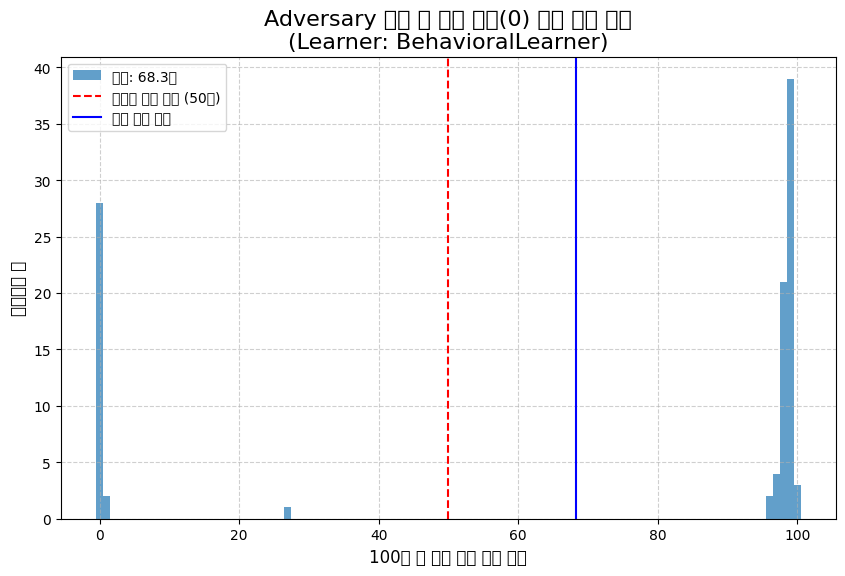

[98, 99, 98, 99, 0, 99, 98, 99, 99, 99, 0, 99, 97, 98, 98, 99, 1, 99, 0, 99, 97, 0, 0, 99, 99, 0, 98, 99, 0, 0, 98, 99, 0, 0, 0, 99, 98, 0, 100, 0, 0, 99, 0, 99, 0, 98, 99, 0, 0, 0, 99, 99, 99, 96, 98, 98, 98, 0, 99, 99, 99, 97, 99, 0, 1, 99, 0, 99, 99, 96, 98, 98, 98, 27, 99, 0, 98, 0, 99, 99, 97, 99, 100, 0, 0, 99, 98, 0, 99, 99, 98, 0, 99, 99, 98, 98, 99, 99, 100, 98]


In [66]:
# 2. 훈련된 Adversary를 '평가 모드'로 다시 실행합니다.
# (is_training=False로 설정하면 Epsilon 탐색을 끄고, 학습도 멈춥니다)


In [3]:

def load_config(config_path="config.yaml"):
    """YAML 설정 파일 로드"""
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    return config


In [6]:
config = load_config("config.yaml")
config.keys()

dict_keys(['TOTAL_TRIALS', 'REWARD_BUDGET_PER_ARM', 'TARGET_ACTION', 'QLearner', 'BehavioralLearner', 'Adversary', 'Evaluation'])

In [ ]:
q_learner = QLearner(alpha=0.1, gamma=0.9, epsilon=0.1)
Experiment(learner_template=q_learner)



In [ ]:
q_learner = QLearner(alpha=0.1, gamma=0.9, epsilon=LEARNER_EPSILON)
experiment_q_learner = Experiment(learner_template=q_learner_template)
experiment_q_learner.run(is_training=True)
experiment_q_learner.run(is_training=False)

# --- 시나리오 2: BehavioralLearner를 상대로 Adversary 훈련 및 평가 ---
# 1. 가상 피험자 데이터 생성
dummy_data = generate_dummy_behavioral_data(num_episodes=50, episode_length=TOTAL_TRIALS)

# 2. BehavioralLearner 생성 및 사전 학습
behavioral_learner_template = BehavioralLearner(
    input_size=BH_MODEL_INPUT_SIZE, 
    hidden_size=BH_MODEL_HIDDEN_SIZE, 
    output_size=ADV_ACTION_SIZE
)
behavioral_learner_template.train_from_data(dummy_data)

# 3. 실험 진행
experiment_bh_learner = Experiment(learner_template=behavioral_learner_template)
experiment_bh_learner.run(is_training=True)
experiment_bh_learner.run(is_training=False)